### Import necessary libraries

In [114]:
import matplotlib.pyplot as plt
import pandas as pd
import re

from matplotlib_venn import venn3
from ast import literal_eval

### Import dataset and a first look

In [115]:
df_games = pd.read_csv("datasets/games_march2025.csv")

df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [116]:
# Summary of statistics for numerical attributes
df_games.describe()

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,89618.000000,39.000000,8.961800e+04,...,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,0.032817,99.128205,1.269896e+03,...,1.149119e+02,5.032694,1.147559e+02,5.301814,4.558627,9.833994e+01,45.352418,1.315490e+03,5.231639,15.584581
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,1.615149,0.695076,3.181441e+04,...,6.814748e+03,181.100334,8.806711e+03,189.591095,16.538036,5.717544e+03,40.685695,3.542370e+04,22.335358,444.277307
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,0.000000,99.000000,1.000000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,60.000000,1.500000e+01,-1.000000,-1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,5.800000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.100000e+01,-1.000000,-1.000000
max,3.542350e+06,21.000000,999.980000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


In [117]:
# Summary of statistics for categorical attributes
df_games.describe(include='object')

,name,release_date,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,...,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,estimated_owners,tags
count,89618,89618,89421,89398,89498,10401,89618,41114,44110,78798,...,89618,89618,89618,89618,89618,89618,89618,89618,89618,89618
unique,88899,4459,89075,89040,88586,10291,89587,33321,29309,48174,...,2882,75740,56478,49798,7471,2689,89482,87183,15,70420
top,Alone,2024-10-31,Help the beautiful girls to immerse themselves in their memories and remember the wonderful moments of their lives. This game is a classic puzzle game with several levels of difficulty and beautiful arts. All characters appearing in this game are over 18 years of age. Enjoy ;-) - Puzzle Game - Artworks - Nice music - Steam achievements Keyboard H: Complete Level,Help the beautiful girls to immerse themselves in their memories and remember the wonderful moments of their lives. This game is a classic puzzle game with several levels of difficulty and beautiful arts. All characters appearing in this game are over 18 years of age. Enjoy ;-) - Puzzle Game - Artworks - Nice music - Steam achievements Keyboard H: Complete Level,Find the objects that are hidden on the map.,“ ” Read more on PC Gamer,https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/750920/header.jpg?t=1729014037,https://www.facebook.com/8FloorGames/,https://www.facebook.com/8FloorGames,info@bigfishgames.com,...,[],[],[],[],"['Single-player', 'Family Sharing']","['Casual', 'Indie']",[],[],0 - 20000,[]
freq,6,141,58,58,50,21,5,247,270,314,...,49823,13819,221,547,19088,5099,106,2411,59320,16872


In [118]:
df_games.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2. A free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools. In addition to the classic objective-focused gameplay that Counter-Strike pioneered in 1999, Counter-Strike 2 features: All-new CS Ratings with the updated Premier mode Global and Regional leaderboards Upgraded and overhauled maps Game-changing dynamic smoke grenades Tick-rate-independent gameplay Redesigned visual effects and audio All items from CS:GO moving forward to CS2","For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2. A free upgrade to CS:GO, Counter-Strike 2 marks the largest technical leap in Counter-Strike’s history. Built on the Source 2 engine, Counter-Strike 2 is modernized with realistic physically-based rendering, state of the art networking, and upgraded Community Workshop tools. In addition to the classic objective-focused gameplay that Counter-Strike pioneered in 1999, Counter-Strike 2 features: All-new CS Ratings with the updated Premier mode Global and Regional leaderboards Upgraded and overhauled maps Game-changing dynamic smoke grenades Tick-rate-independent gameplay Redesigned visual effects and audio All items from CS:GO moving forward to CS2","For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2.",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer': 62332, 'Competitive': 53359, 'Action': 47512, 'Team-Based': 46430, 'e-sports': 43533, 'Tactical': 41354, 'First-Person': 39414, 'PvP': 34470, 'Online Co-Op': 33966, 'Co-op': 30263, 'Strategy': 30111, 'Military': 28699, 'War': 28006, 'Difficult': 25966, 'Trading': 25717, 'Realistic': 25430, 'Fast-Paced': 25318, 'Moddable': 6603}",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS for free. Land on strategic locations, loot weapons and supplies, and survive to become the last team standing across various, diverse Battlegrounds. Squad up and join the Battlegrounds for the original Battle Royale experience that only PUBG: BATTLEGROUNDS can offer. This content download will also provide access to the BATTLEGROUNDS Test Server, which requires a separate download to play. Optional in-game purchases available.","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS for free. Land on strategic locations, loot weapons and supplies, and survive to become the last team standing across various, diverse Battlegrounds. Squad up and join the Battlegrounds for the original Battle Royale experience that only PUBG: BATTLEGROUNDS can offer. This content download will also provide access to the BATTLEGROUNDS Test Server, which requires a separate download to play. Optional in-game purchases available.","Play PUBG: BATTLEGROUNDS for free. Land on strategic locations, loot weapons and supplies, and survive to become the last team standing across various, diverse Battlegrounds. Squad up and join the Battlegrounds for the original Battle Royale exper

### Dealing with null value
A *percentage stacked bar chart* of non-null values in the dataset<br>

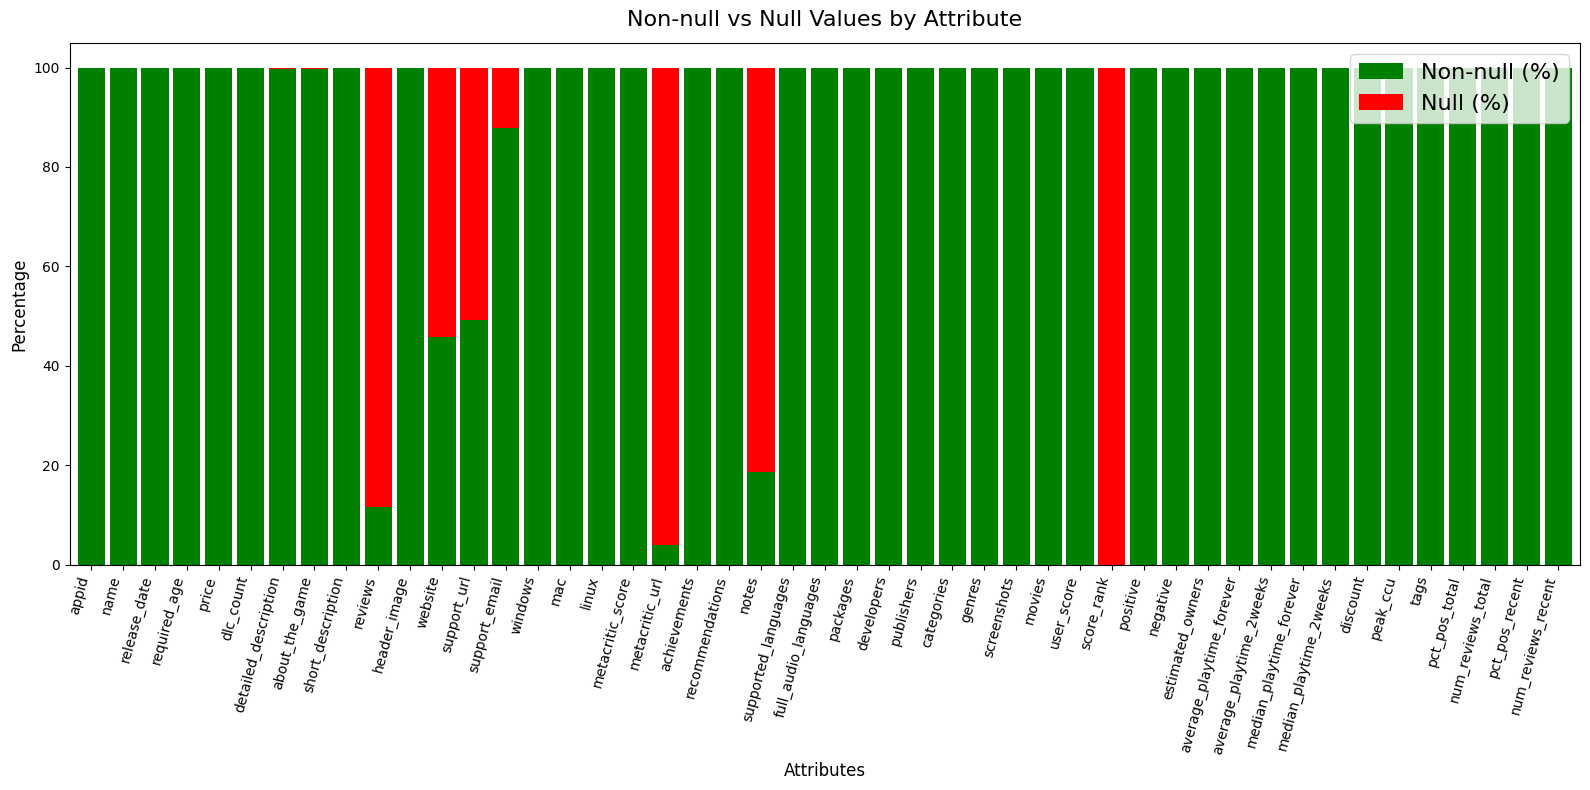

In [119]:
null_pct = df_games.isna().mean() * 100
non_null_pct = 100 - null_pct

plot_df = pd.DataFrame({
    'Non-null (%)': non_null_pct,
    'Null (%)': null_pct
})

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 8),
    color=['green', 'red'],
    width=0.85
)

ax.set_ylabel('Percentage', fontsize=12)
ax.set_xlabel('Attributes', fontsize=12)
ax.set_title('Non-null vs Null Values by Attribute', fontsize=16, pad=12)
ax.legend(loc='upper right', fontsize=16)
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

After the visualization, the following attributes will be excluded from the subsequent elaboration due to high percentage of null values:<br>
1. reviews
2. metascritic_url
3. notes
4. score_rank

In [120]:
df_games = df_games.drop(['reviews', 'metacritic_url', 'notes', 'score_rank'], axis=1)

While *website* and *support_url* retain around 50% of values, these two attributes do not provide any useful information for the analysis of the dataset, and therefore dropped

In [121]:
df_games = df_games.drop(['website', 'support_url'], axis=1)

### Analyzing **URL** attributes *support_email*, *header_image*, *screenshots*, and *movies*

In [122]:
# Fill the missing values in the analyzed columns with 'missing'
df_games['header_image'] = df_games['header_image'].fillna('missing')
df_games['support_email'] = df_games['support_email'].fillna('missing')
df_games['screenshots'] = df_games['screenshots'].fillna('missing')
df_games['movies'] = df_games['movies'].fillna('missing')

The *header_image*, *screenshots*, and *movies* attributes contain URLs to external multimedia data storage, which are deemed useless for the purpose of this project, therefore, they are dropped from the subsequent analysis

In [123]:
print(df_games[['header_image', 'screenshots', 'movies']])

                                                                                                                                      header_image  \
0                                                   https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/730/header.jpg?t=1729703045   
1                                                https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/578080/header.jpg?t=1736389084   
2                                                   https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/570/header.jpg?t=1739210483   
3                                                https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/271590/header.jpg?t=1741120008   
4                                                https://shared.akamai.steamstatic.com/store_item_assets/steam/apps/359550/header.jpg?t=1741397094   
...                                                                                                 

The bar chart shows the frequencies of each unique values in *support_email* attribute, which serves as the same function as *website*, providing an official contact to each game, it is meaningful on its own. However its function is outside the scope of this analysis, and it will be dropped

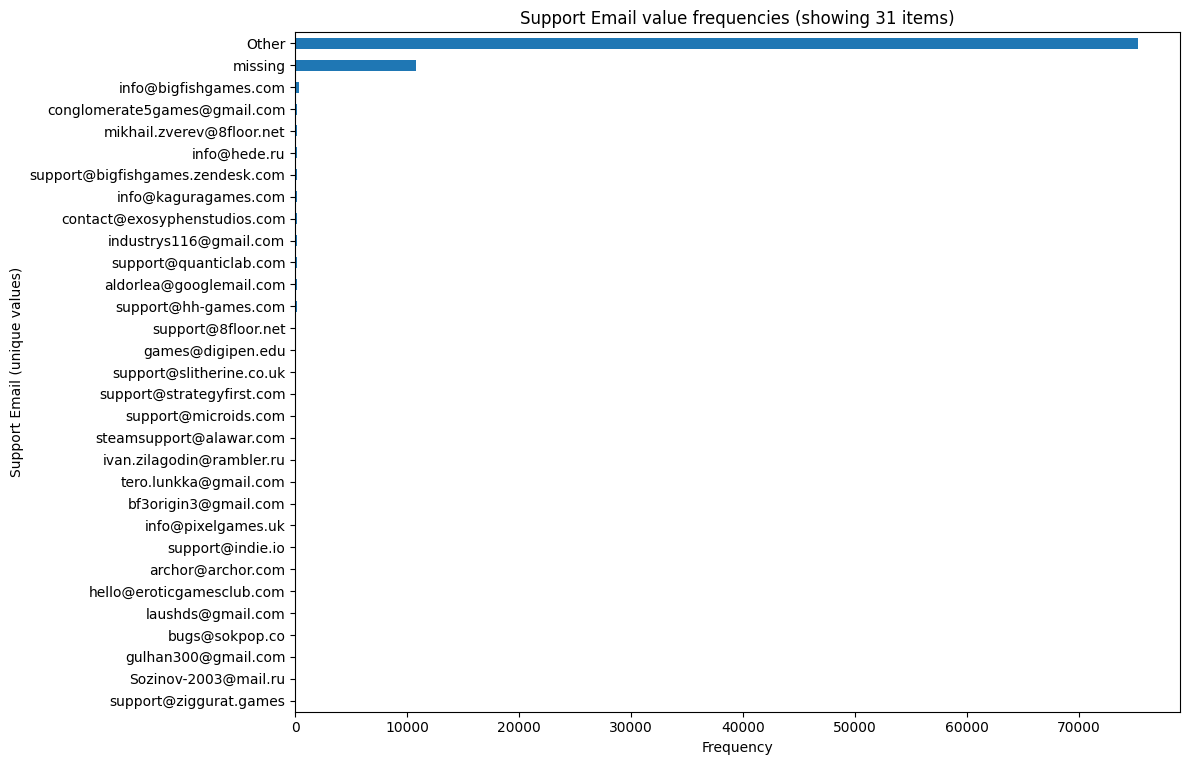

In [124]:
# plot frequencies of unique values in df_games['support_email']
counts = df_games['support_email'].value_counts()
max_bars = 30
if len(counts) > max_bars:
    top = counts.head(max_bars).copy()
    top['Other'] = counts.iloc[max_bars:].sum()
else:
    top = counts.copy()

ax_support_email = top.sort_values().plot(
    kind='barh',
    figsize=(12, max(6, 0.25 * len(top))),
    color='tab:blue'
)
ax_support_email.set_xlabel('Frequency')
ax_support_email.set_ylabel('Support Email (unique values)')
ax_support_email.set_title(f"Support Email value frequencies (showing {len(top)} items)")

plt.tight_layout()
plt.show()

In [125]:
df_games = df_games.drop(['header_image', 'support_email', 'screenshots', 'movies'], axis=1)

### Comparison between *about_the_game* and *detailed_description*
The bar chart shows the number of items with the same values for the analyzed attributes.<br>

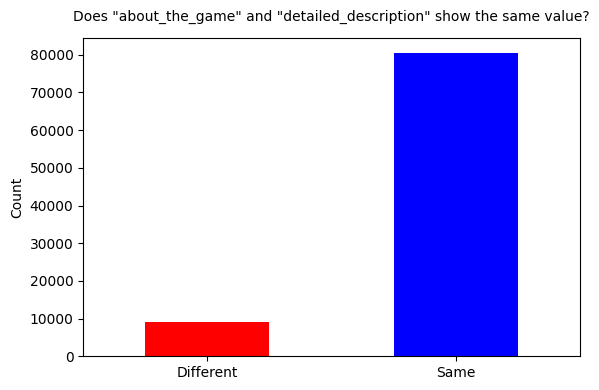

In [126]:
# Compare without adding a new column to df_games
comparison_counts = (df_games['about_the_game'] == df_games['detailed_description']).value_counts().reindex([False, True], fill_value=0)

ax = comparison_counts.plot(
    kind='bar',
    figsize=(6, 4),
    color=['red', 'blue']
)

ax.set_xticklabels(['Different', 'Same'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Does "about_the_game" and "detailed_description" show the same value?', fontsize=10, pad=12)

plt.tight_layout()
plt.show()

Because the majority of the items have the same values, *detailed_description* is arbitrarily dropped

In [127]:
df_games = df_games.drop(['detailed_description'], axis=1)

### Comparison between *about_the_game* and *short_description*
Following the same format, the bar chart show the number of items with same information in the two analyzed attributes, results shows that the most of items have different values.

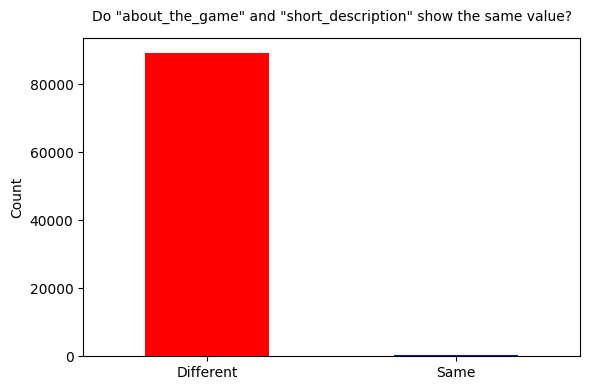

In [128]:
# Compare without adding a new column to df_games
comparison_counts = (df_games['about_the_game'] == df_games['short_description']).value_counts().reindex([False, True], fill_value=0)

ax = comparison_counts.plot(
    kind='bar',
    figsize=(6, 4),
    color=['red', 'blue']
)

ax.set_xticklabels(['Different', 'Same'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Do "about_the_game" and "short_description" show the same value?', fontsize=10, pad=12)

plt.tight_layout()
plt.show()

Because the two attributes are redundant on their function, i.e., providing a description on each game, a bar chart is provided showing the max number of characters and mean number of characters in each attributes <br>
Result shows that *short_description* contains much less characters than *about_the_game*, with the goal to trim down the size of dataset, *about_the_game* is dropped

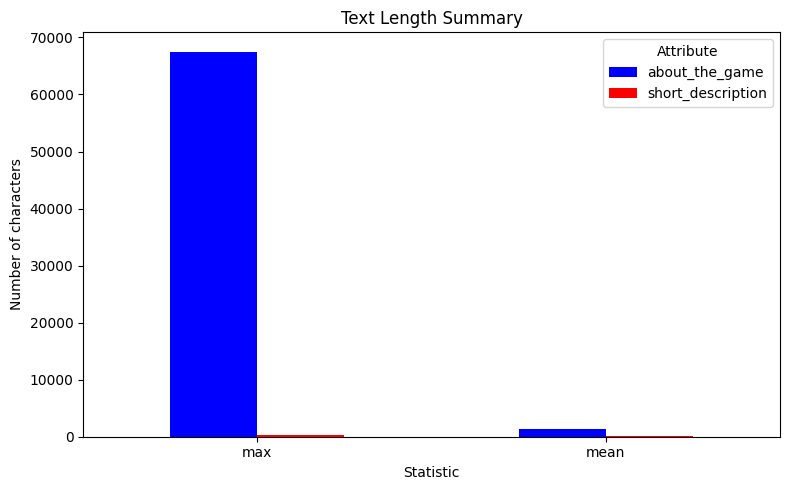

In [129]:
summary_table = pd.DataFrame({
    'max': [df_games['about_the_game'].str.len().max(), df_games['short_description'].str.len().max()],
    'mean': [df_games['about_the_game'].str.len().mean(), df_games['short_description'].str.len().mean()]
}, index=['about_the_game', 'short_description'])

summary_table = summary_table.round(2)

ax = summary_table.T.plot(
    kind='bar',
    figsize=(8, 5),
    color=['blue', 'red']
)

ax.set_ylabel('Number of characters')
ax.set_xlabel('Statistic')
ax.set_title('Text Length Summary')
ax.legend(title='Attribute')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [130]:
df_games = df_games.drop(['about_the_game'], axis=1)

In [131]:
# Fill the missing values in 'short_description' with 'No description available'
df_games['short_description'] = df_games['short_description'].fillna('No description available')

### *supported_languages* and *full_audio_languages* cleaning

In [132]:
# Serialize the supported_languages column by splitting the comma-separated values and exploding the list into individual rows
langs_series = df_games['supported_languages'].fillna('missing').str.split(',').explode().str.strip()

# Clean the langs_series by replacing malformed entries
langs_series = langs_series.str.replace(r'^\s+', '', regex=True)  # Remove leading whitespace
langs_series = langs_series.str.replace(r'\s+$', '', regex=True)  # Remove trailing whitespace
langs_series = langs_series.str.replace(r"[' \"]", '', regex=True)  # Remove quotes
langs_series = langs_series.str.replace(r'[\[\]]', '', regex=True)  # Remove square brackets
langs_series = langs_series.str.replace(r'b/b', '', regex=True)  # Remove b/b artifacts
langs_series = langs_series.str.replace(r'\\r\\n', '', regex=True)  # Remove \r\n

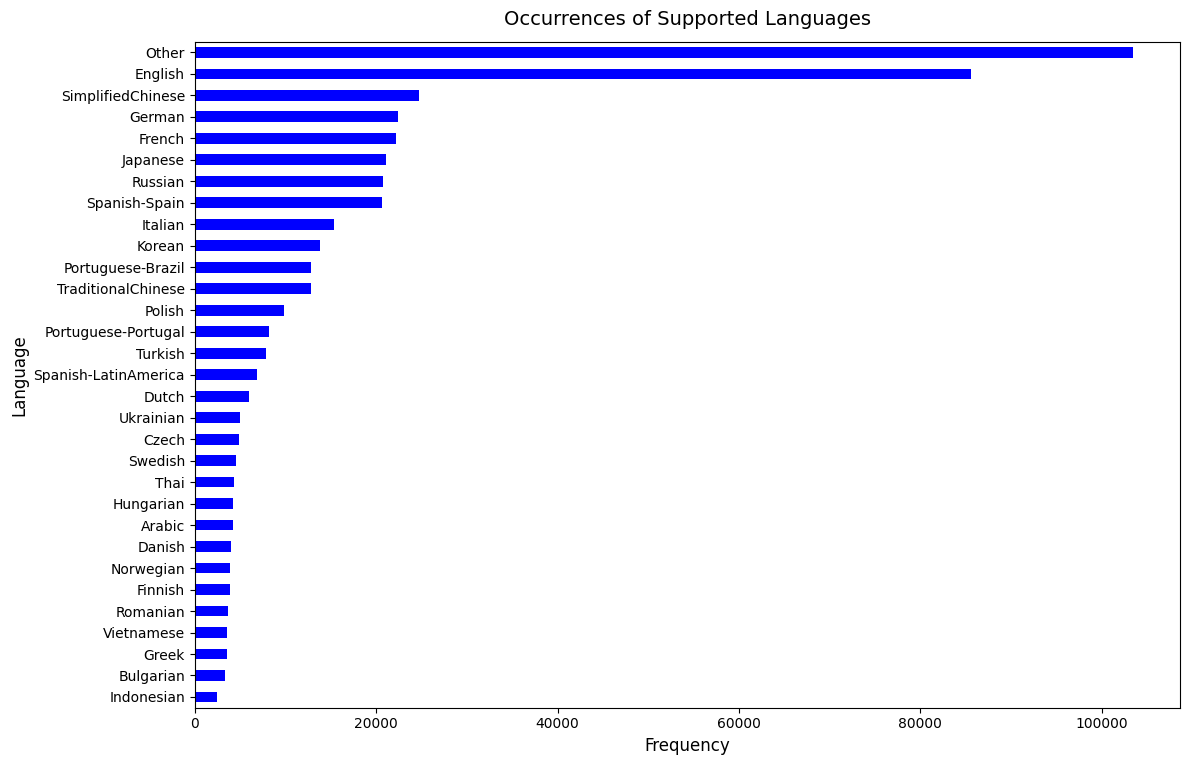

In [133]:
# Count occurrences of each language
lang_counts = langs_series.value_counts().sort_values(ascending=False)
max_bars = 30
if len(lang_counts) > max_bars:
    top = lang_counts.head(max_bars).copy()
    top['Other'] = lang_counts.iloc[max_bars:].sum()
else:
    top = lang_counts.copy()
# Create horizontal bar chart

ax = top.sort_values().plot(
    kind='barh',
    figsize=(12, max(6, 0.25 * len(top))),
    color='blue'
)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_ylabel('Language', fontsize=12)
ax.set_title('Occurrences of Supported Languages', fontsize=14, pad=12)

plt.tight_layout()
plt.show()

Both *support_languages* and *full_audio_languages* will be used as a metric for evaluate user accessibility. However, we are more interested in assessing how many languages does a game support instead of how many games support a certain language.<br>

In [134]:
# add a column with the number of supported languages per item
df_games['num_supported_languages'] = df_games['supported_languages'].fillna('').astype(str).map(lambda s: 0 if s.strip().lower() in ['', 'missing'] else len([p for p in s.split(',') if p.strip()]))

# add a column with the number of audio languages per item
df_games['num_audio_languages'] = df_games['full_audio_languages'].fillna('').astype(str).map(lambda s: 0 if s.strip().lower() in ['', 'missing'] else len([p for p in s.split(',') if p.strip()]))

In [135]:
df_games = df_games.drop(['supported_languages', 'full_audio_languages'], axis=1)

### *packages* cleaning
The attribute shows in full describes all the available variations(editions) of the same game, including title, description, and price.<br>
Because the redundancy, this attribute is dropped

In [136]:
pd.set_option('display.max_colwidth', None)
print(df_games[['packages']].head(5).to_string(index=False))

In [137]:
df_games = df_games.drop(['packages'], axis=1)

### *tags*, *categories*, and *genres* attributes intersection
A preliminary check at the three analyzed attribute show that almost of *genres*'s value can be found under *tags* therefore creating a redundancy; while *categories* shows only a small overlap with *tags*, a further checks shows that more than half of its values (like "commentary available", "Family sharing", "Steam Achievements" and so on) are not interesting for the purpose of this project, and others differ only in spelling, for example, "single player" in *categories* and "singleplayer" in *tags*.<br>
As a consequence, the *categories* and *genres* attributes are deemed redundant, and therefore dropped.

In [149]:
# A quick check of the first row of the tags, categories, and genres columns to understand their structure
print(df_games['tags'].iloc[0])
print(df_games['categories'].iloc[0])
print(df_games['genres'].iloc[0])

print(type(df_games['tags'].iloc[0]))
print(type(df_games['categories'].iloc[0]))
print(type(df_games['genres'].iloc[0]))

{'fps': 90857, 'shooter': 65397, 'multiplayer': 62332, 'competitive': 53359, 'action': 47512, 'team_based': 46430, 'e_sports': 43533, 'tactical': 41354, 'first_person': 39414, 'pvp': 34470, 'online_co_op': 33966, 'co_op': 30263, 'strategy': 30111, 'military': 28699, 'war': 28006, 'difficult': 25966, 'trading': 25717, 'realistic': 25430, 'fast_paced': 25318, 'moddable': 6603}
['multi_player', 'cross_platform_multiplayer', 'steam_trading_cards', 'steam_workshop', 'in_app_purchases', 'valve_anti_cheat_enabled', 'stats', 'remote_play_on_phone', 'remote_play_on_tablet', 'remote_play_on_tv', 'steam_timeline']
['action', 'free_to_play']
<class 'dict'>
<class 'list'>
<class 'list'>


In [150]:
# Define a normalization helper function to normalize strings for consistent comparison and analysis
def normalize_key(key):
    key = str(key).lower().strip()  # Convert to string, lowercase, and trim whitespace
    key = re.sub(r"[^a-z0-9]+", "_", key)  # Replace non-alphanumeric sequences with '_'
    key = key.strip("_")  # Remove leading/trailing underscores
    return key

In [ ]:
# Define a function to normalize the 'tags' column, which contains string representations of dictionaries
def normalize_dict(x):
    if pd.isna(x):
        return {}

    parsed = literal_eval(str(x))

    # Convert empty lists to empty dictionaries
    # The column initially contains string representations of dictionaries, but some entries are empty lists instead of empty dictionaries
    if isinstance(parsed, list):
        if len(parsed) == 0:
            return {}
        else:
            raise ValueError(f"Unexpected non-empty list: {parsed}")

    if isinstance(parsed, dict):
        return {normalize_key(k): v for k, v in parsed.items()}

    raise ValueError(f"Unexpected type: {type(parsed)}")


# Normalize the entire column
df_games["tags"] = df_games["tags"].apply(normalize_dict)

# Extract all unique normalized keys
tags_unique = sorted({key for d in df_games["tags"] for key in d.keys()})

In [ ]:
# Analogously, define a function to normalize the list type columns (categories and genres), which contains string representations of lists
def normalize_list(x):
    if pd.isna(x):
        return []

    parsed = literal_eval(str(x))

    if isinstance(parsed, list):
        return [normalize_key(item) for item in parsed]

    raise ValueError(f"Expected a list, got {type(parsed)}")


# Normalize the entire column
df_games["categories"] = df_games["categories"].apply(normalize_list)

# Extract all unique normalized values
categories_unique = sorted({value for lst in df_games["categories"] for value in lst})

In [ ]:
# Normalize the genres column and extract unique normalized values
df_games['genres'] = df_games['genres'].apply(normalize_list)

# Extract all unique normalized values
genres_unique = sorted({value for lst in df_games['genres'] for value in lst})

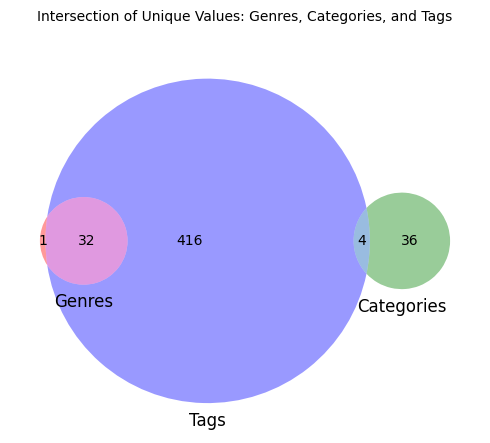

In [ ]:
# Convert lists of unique values to sets for Venn diagram
genres_set = set(genres_unique)
categories_set = set(categories_unique)
tags_set = set(tags_unique)

# Create Venn diagram
plt.figure(figsize=(5, 5))
venn3([genres_set, categories_set, tags_set], 
      set_labels=('Genres', 'Categories', 'Tags'))
plt.title('Intersection of Unique Values: Genres, Categories, and Tags', fontsize=10, pad=20)
plt.tight_layout()
plt.show()